In [ ]:
# 🔬 Validação Cruzada e Mais Modelos

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Carregar dados
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print("✅ Dados carregados. Iniciando validação cruzada...")

In [5]:
# 📖 O QUE É VALIDAÇÃO CRUZADA?

# Antes: treino/teste fixo (80/20). O modelo vê os dados UMA vez.
# Agora: dividimos os dados em 5 partes (folds). 
# O modelo treina em 4 e testa em 1, repetindo 5 vezes.
# Resultado: média das 5 acurácias. Muito mais confiável!

print("""
┌──────────────────────────────────────────┐
│  Fold 1: [Treino Treino Treino Treino] [Teste]  │
│  Fold 2: [Treino Treino Treino] [Teste] [Treino]│
│  Fold 3: [Treino Treino] [Teste] [Treino Treino]│
│  Fold 4: [Treino] [Teste] [Treino Treino Treino]│
│  Fold 5: [Teste] [Treino Treino Treino Treino]  │
└──────────────────────────────────────────┘
""")


┌──────────────────────────────────────────┐
│  Fold 1: [Treino Treino Treino Treino] [Teste]  │
│  Fold 2: [Treino Treino Treino] [Teste] [Treino]│
│  Fold 3: [Treino Treino] [Teste] [Treino Treino]│
│  Fold 4: [Treino] [Teste] [Treino Treino Treino]│
│  Fold 5: [Teste] [Treino Treino Treino Treino]  │
└──────────────────────────────────────────┘



In [7]:
# Definir modelos
modelos = {
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# Validação cruzada (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}

for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X, y, cv=cv, scoring='accuracy')
    resultados[nome] = {
        'Média': scores.mean(),
        'Desvio Padrão': scores.std(),
        'Mínimo': scores.min(),
        'Máximo': scores.max()
    }
    print(f"✅ {nome}: Média = {scores.mean():.4f} (±{scores.std():.4f})")

# Criar DataFrame
df_resultados = pd.DataFrame(resultados).T
print("\n📊 Tabela de Resultados:")
df_resultados

✅ KNN (k=3): Média = 0.9533 (±0.0499)
✅ Árvore de Decisão: Média = 0.9533 (±0.0340)
✅ Random Forest: Média = 0.9467 (±0.0267)
✅ SVM: Média = 0.9667 (±0.0298)

📊 Tabela de Resultados:


,Média,Desvio Padrão,Mínimo,Máximo
KNN (k=3),0.953333,0.049889,0.866667,1.000000
Árvore de Decisão,0.953333,0.033993,0.900000,1.000000
Random Forest,0.946667,0.026667,0.900000,0.966667
SVM,0.966667,0.029814,0.933333,1.000000


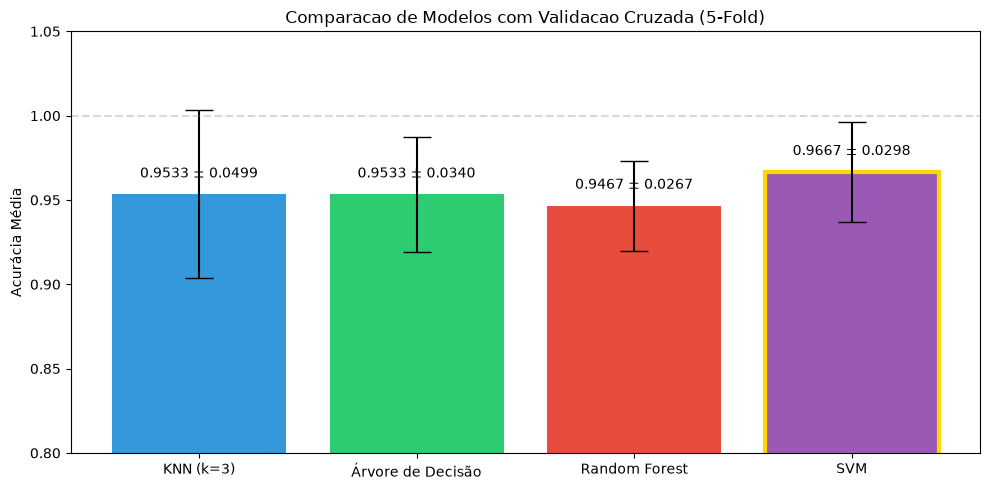

In [9]:
# Gráfico de barras com desvio padrão
modelos_nomes = list(resultados.keys())
medias = [resultados[m]['Média'] for m in modelos_nomes]
desvios = [resultados[m]['Desvio Padrão'] for m in modelos_nomes]

plt.figure(figsize=(10, 5))
bars = plt.bar(modelos_nomes, medias, yerr=desvios, capsize=10,
               color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])

# Destacar o melhor
melhor_idx = medias.index(max(medias))
bars[melhor_idx].set_edgecolor('gold')
bars[melhor_idx].set_linewidth(3)

plt.ylim(0.8, 1.05)
plt.ylabel('Acurácia Média')
plt.title('Comparacao de Modelos com Validacao Cruzada (5-Fold)')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

# Adicionar valor em cima de cada barra
for bar, media, desvio in zip(bars, medias, desvios):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{media:.4f} ± {desvio:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

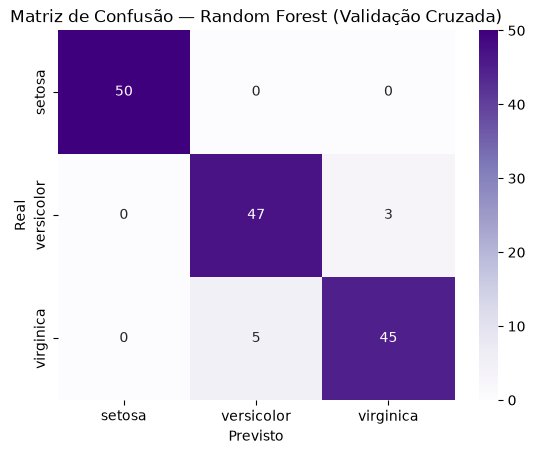

In [10]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

# Melhor modelo: Random Forest (geralmente)
melhor_modelo = RandomForestClassifier(random_state=42)
y_pred_cv = cross_val_predict(melhor_modelo, X, y, cv=cv)

# Matriz de confusão
cm = confusion_matrix(y, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Matriz de Confusão — Random Forest (Validação Cruzada)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

In [11]:
# Encontrar o melhor modelo
melhor_nome = max(resultados, key=lambda m: resultados[m]['Média'])
melhor_media = resultados[melhor_nome]['Média']
melhor_desvio = resultados[melhor_nome]['Desvio Padrão']

print(f"""
╔══════════════════════════════════════╗
║           RESULTADO FINAL            ║
╠══════════════════════════════════════╣
║ Melhor modelo: {melhor_nome:<20} ║
║ Acurácia:      {melhor_media:.4f} ± {melhor_desvio:.4f}          ║
║ Técnica:       Validação Cruzada      ║
║ Folds:         5                      ║
╚══════════════════════════════════════╝
""")


╔══════════════════════════════════════╗
║           RESULTADO FINAL            ║
╠══════════════════════════════════════╣
║ Melhor modelo: SVM                  ║
║ Acurácia:      0.9667 ± 0.0298          ║
║ Técnica:       Validação Cruzada      ║
║ Folds:         5                      ║
╚══════════════════════════════════════╝

